<a href="https://colab.research.google.com/github/ketanp23/LLMclass/blob/main/Lab2_RNNs_and_LSTMs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2 · RNNs & LSTMs

**Course:** Language Models — From N-grams to Transformers
**Goal:** Build recurrent language models that read text one token at a time and carry a *hidden state*.

You will:
- Build a **character-level** RNN and LSTM in PyTorch
- Train them to predict the next character and **generate** text
- See *why* plain RNNs struggle with long sequences (**vanishing gradients**)
- Understand how the **LSTM's gates** fix this

> **Runtime tip:** set `Runtime → Change runtime type → T4 GPU` for a speed-up (works on CPU too, just slower).

## 1 · Setup

PyTorch is preinstalled on Colab.

In [1]:
import torch
import torch.nn as nn
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch", torch.__version__, "| device:", device)
torch.manual_seed(0)

PyTorch 2.11.0+cu128 | device: cuda


## 2 · Data — character-level

Character-level modelling keeps the vocabulary tiny (just the unique characters), so we can train quickly and focus on the *architecture*. We'll use a short passage; swap in any text you like.

In [2]:
text = (
    "the quick brown fox jumps over the lazy dog. "
    "she sells sea shells by the sea shore. "
    "a language model learns to predict the next token. "
    "recurrent networks carry a hidden state through time. "
) * 40   # repeat so there is enough to learn from

chars = sorted(set(text))
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for c, i in stoi.items()}
vocab_size = len(chars)
print(f"Corpus length: {len(text)} chars | vocabulary: {vocab_size} unique chars")
print("Characters:", "".join(chars))

data = torch.tensor([stoi[c] for c in text], dtype=torch.long)

Corpus length: 7560 chars | vocabulary: 28 unique chars
Characters:  .abcdefghijklmnopqrstuvwxyz


## 3 · Mini-batches of sequences

We chop the stream into overlapping windows. For each input window `x`, the target `y` is the same window shifted one character to the right (predict-the-next-char).

In [3]:
SEQ_LEN = 40
BATCH   = 32

def get_batch(data, seq_len=SEQ_LEN, batch=BATCH):
    ix = torch.randint(0, len(data) - seq_len - 1, (batch,))
    x = torch.stack([data[i:i + seq_len] for i in ix])
    y = torch.stack([data[i + 1:i + seq_len + 1] for i in ix])
    return x.to(device), y.to(device)

xb, yb = get_batch(data)
print("input  batch:", xb.shape)   # (batch, seq_len)
print("target batch:", yb.shape)
print("\nExample  x:", "".join(itos[i.item()] for i in xb[0]))
print("Example  y:", "".join(itos[i.item()] for i in yb[0]))

input  batch: torch.Size([32, 40])
target batch: torch.Size([32, 40])

Example  x:  brown fox jumps over the lazy dog. she 
Example  y: brown fox jumps over the lazy dog. she s


## 4 · A vanilla RNN

The core recurrence: at each step combine the current input with the previous hidden state.

$$h_t = \tanh(W_x x_t + W_h h_{t-1} + b)$$

PyTorch's `nn.RNN` implements exactly this. We wrap it with an embedding lookup and an output projection to vocabulary logits.

In [4]:
class CharModel(nn.Module):
    """A char-level language model. cell = 'rnn' or 'lstm'."""
    def __init__(self, vocab_size, embed=64, hidden=128, cell="rnn"):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed)
        if cell == "rnn":
            self.rnn = nn.RNN(embed, hidden, batch_first=True)
        else:
            self.rnn = nn.LSTM(embed, hidden, batch_first=True)
        self.head = nn.Linear(hidden, vocab_size)
        self.cell = cell

    def forward(self, x, state=None):
        x = self.embed(x)                 # (B, T, embed)
        out, state = self.rnn(x, state)   # (B, T, hidden)
        logits = self.head(out)           # (B, T, vocab)
        return logits, state

rnn_model = CharModel(vocab_size, cell="rnn").to(device)
n_params = sum(p.numel() for p in rnn_model.parameters())
print(f"RNN model ready — {n_params:,} parameters")

RNN model ready — 30,236 parameters


## 5 · Training loop

We minimise cross-entropy between predicted and actual next characters.

In [5]:
def train(model, steps=1500, lr=3e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    model.train()
    losses = []
    for step in range(steps):
        xb, yb = get_batch(data)
        logits, _ = model(xb)
        loss = loss_fn(logits.reshape(-1, vocab_size), yb.reshape(-1))
        opt.zero_grad(); loss.backward(); opt.step()
        losses.append(loss.item())
        if step % 300 == 0 or step == steps - 1:
            print(f"step {step:4d} | loss {loss.item():.3f}")
    return losses

print("Training the vanilla RNN...")
rnn_losses = train(rnn_model)

Training the vanilla RNN...
step    0 | loss 3.365
step  300 | loss 0.070
step  600 | loss 0.067
step  900 | loss 0.068
step 1200 | loss 0.061
step 1499 | loss 0.071


## 6 · Generate text

Feed the model a seed, sample the next character from its output distribution, append it, and repeat — carrying the hidden state forward, exactly like at training time.

In [6]:
@torch.no_grad()
def generate(model, seed="the ", length=200, temperature=0.8):
    model.eval()
    idx = torch.tensor([[stoi[c] for c in seed]], device=device)
    state = None
    logits, state = model(idx, state)
    out = list(seed)
    last = idx[:, -1:]
    for _ in range(length):
        logits, state = model(last, state)
        probs = torch.softmax(logits[:, -1, :] / temperature, dim=-1)
        nxt = torch.multinomial(probs, 1)
        out.append(itos[nxt.item()])
        last = nxt
    return "".join(out)

print("RNN sample:\n")
print(generate(rnn_model))

RNN sample:

the boxt token. recurrent networks carry a hidden state through time. the quick brown fox jumps over the lazy dog. she sells sea shells by the sea shore. a language model learns to predict the next token.


## 7 · Now an LSTM

**LSTMs** add a protected *cell state* and three **gates**:
- **Forget gate** — what to erase from memory
- **Input gate** — what new information to store
- **Output gate** — what to expose as the hidden state

This lets gradients flow across many steps, so the model remembers longer. We reuse the exact same class with `cell="lstm"`.

In [7]:
lstm_model = CharModel(vocab_size, cell="lstm").to(device)
print("Training the LSTM...")
lstm_losses = train(lstm_model)

print("\nLSTM sample:\n")
print(generate(lstm_model))

Training the LSTM...
step    0 | loss 3.333
step  300 | loss 0.063
step  600 | loss 0.068
step  900 | loss 0.067
step 1200 | loss 0.064
step 1499 | loss 0.065

LSTM sample:

the lazy dog. she sells sea shells by the sea shore. a language model learns to predict the next token. recurrent networks carry a hidden state through time. the quick brown fox jumps over the lazy dog. s


## 8 · Compare training curves

The LSTM typically reaches a **lower loss** and produces more coherent text, especially as sequences get longer.

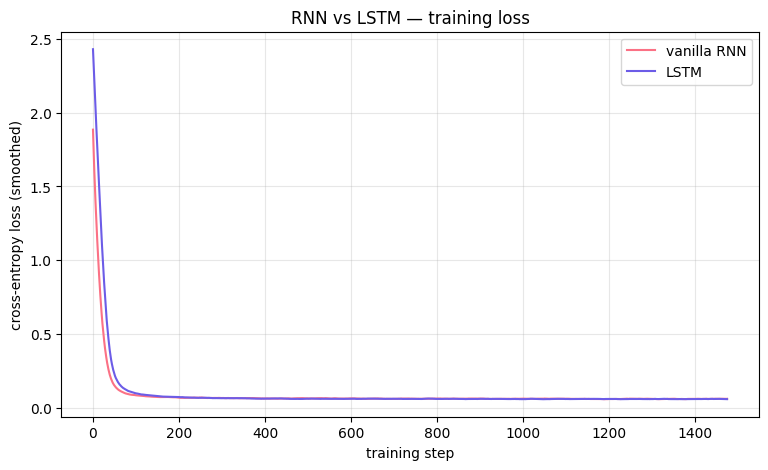

In [8]:
import matplotlib.pyplot as plt

def smooth(x, k=25):
    return np.convolve(x, np.ones(k) / k, mode="valid")

plt.figure(figsize=(9, 5))
plt.plot(smooth(rnn_losses),  label="vanilla RNN", color="#FB7185")
plt.plot(smooth(lstm_losses), label="LSTM",        color="#6C5CE7")
plt.xlabel("training step"); plt.ylabel("cross-entropy loss (smoothed)")
plt.title("RNN vs LSTM — training loss")
plt.legend(); plt.grid(alpha=0.3); plt.show()

## 9 · The vanishing gradient, illustrated

Why do plain RNNs forget? During backpropagation-through-time, gradients get multiplied at every step. If those factors are < 1, the signal **shrinks exponentially** the further back you go — so early tokens receive almost no learning signal.

The cell below measures the gradient norm at each time step for a long sequence. Watch it collapse toward zero for the RNN.

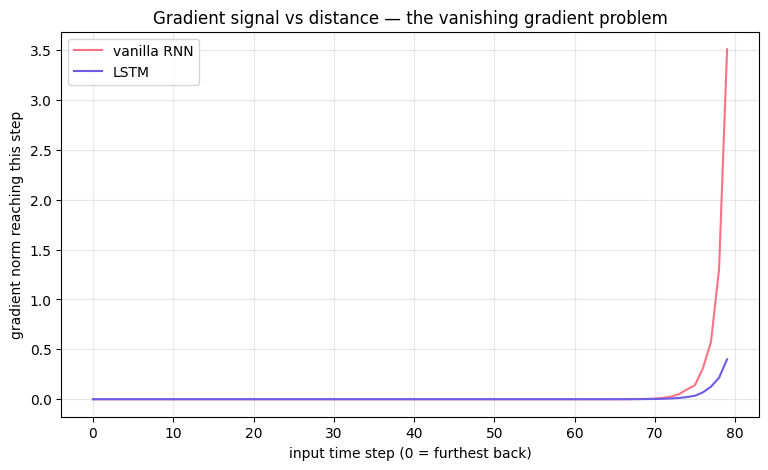

Notice how the RNN's gradient collapses for early time steps,
while the LSTM keeps a usable signal much further back.


In [9]:
def gradient_by_timestep(cell="rnn", seq_len=80):
    model = CharModel(vocab_size, cell=cell).to(device)
    x = data[:seq_len].unsqueeze(0).to(device)
    emb = model.embed(x)
    emb.retain_grad()
    out, _ = model.rnn(emb)
    # Loss only on the LAST step: how much does each earlier input matter?
    loss = out[:, -1, :].pow(2).sum()
    loss.backward()
    grads = emb.grad[0].norm(dim=-1).detach().cpu().numpy()  # per timestep
    return grads

rnn_grad  = gradient_by_timestep("rnn")
lstm_grad = gradient_by_timestep("lstm")

plt.figure(figsize=(9, 5))
plt.plot(rnn_grad,  label="vanilla RNN", color="#FB7185")
plt.plot(lstm_grad, label="LSTM",        color="#6C5CE7")
plt.xlabel("input time step (0 = furthest back)")
plt.ylabel("gradient norm reaching this step")
plt.title("Gradient signal vs distance — the vanishing gradient problem")
plt.legend(); plt.grid(alpha=0.3); plt.show()
print("Notice how the RNN's gradient collapses for early time steps,")
print("while the LSTM keeps a usable signal much further back.")

## 10 · Limitations that motivate attention

Even the LSTM has real weaknesses:
- **Sequential computation** — step *t* must wait for step *t−1*, so training can't be fully parallelised.
- **Fixed-size memory** — the whole past is squeezed into one hidden vector.
- **Long-range decay** — very distant dependencies still fade.

These are exactly the problems the **attention mechanism** (Lab 3) was designed to solve.

## 11 · Your turn 🧪

1. **Longer memory:** increase `SEQ_LEN` to 120 and retrain. Does the gap between RNN and LSTM widen?
2. **Capacity:** change `hidden=256`. Better text? More overfitting?
3. **Temperature:** call `generate(lstm_model, temperature=0.3)` and `temperature=1.3`. What does temperature control?
4. **Your text:** replace `text` with a paragraph of your own and retrain.
5. **Stretch:** swap `nn.LSTM` for `nn.GRU` (a lighter gated cell). How does it compare?

In [10]:
# Scratch space for your experiments
